<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4746 entries, 0 to 4745
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Posted On          4084 non-null   object
 1   BHK                3963 non-null   object
 2   Size               3826 non-null   object
 3   Floor              3960 non-null   object
 4   Area Type          3804 non-null   object
 5   Area Locality      4146 non-null   object
 6   City               4091 non-null   object
 7   Furnishing Status  4042 non-null   object
 8   Tenant Preferred   4094 non-null   object
 9   Bathroom           4205 non-null   object
 10  Point of Contact   4137 non-null   object
 11  Rent               4746 non-null   int64 
dtypes: int64(1), object(11)
memory usage: 445.1+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4746 entries, 0 to 4745
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             ---

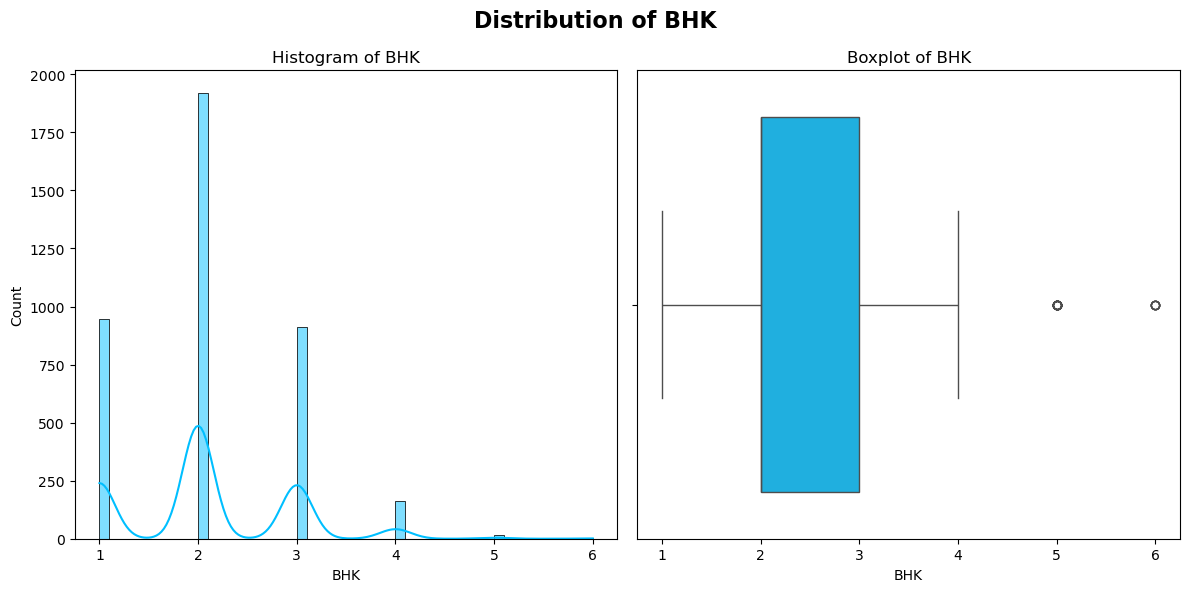

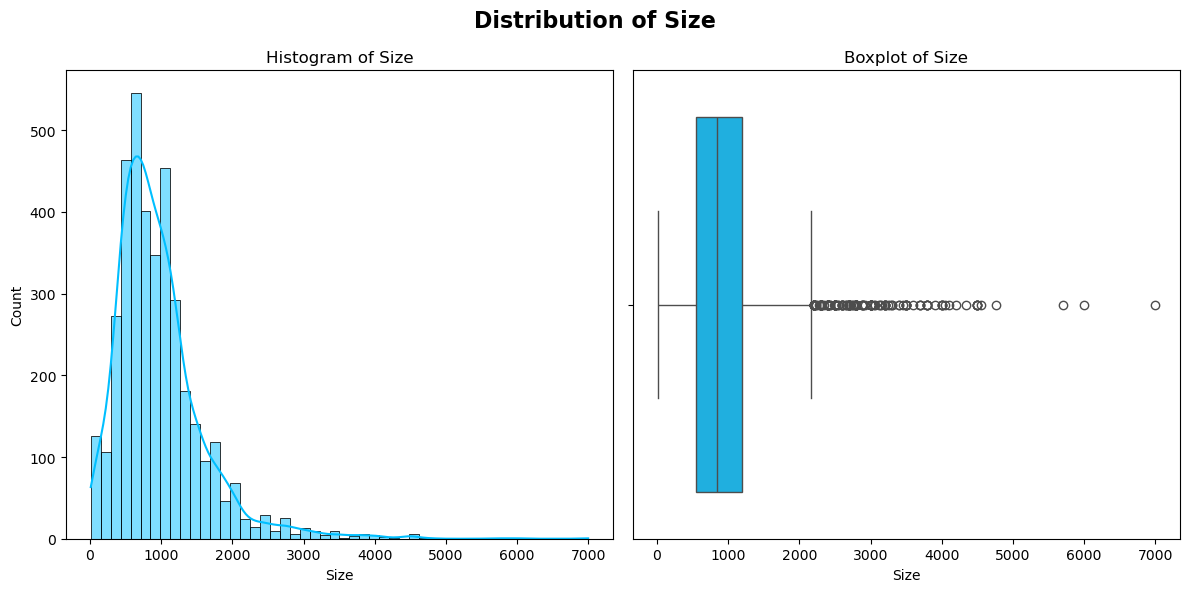

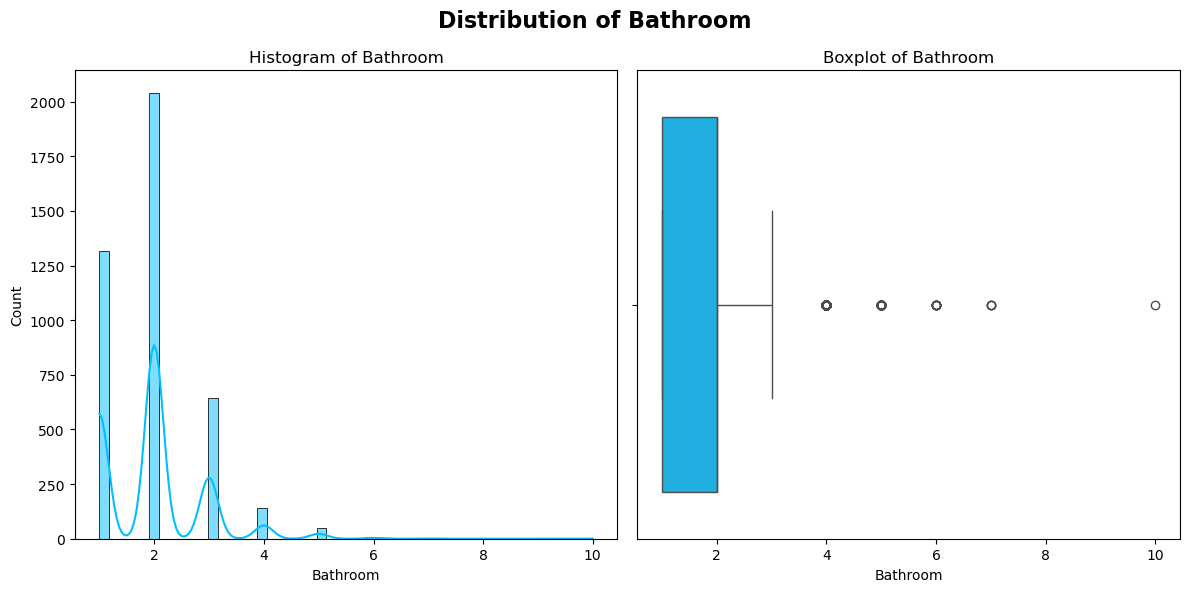

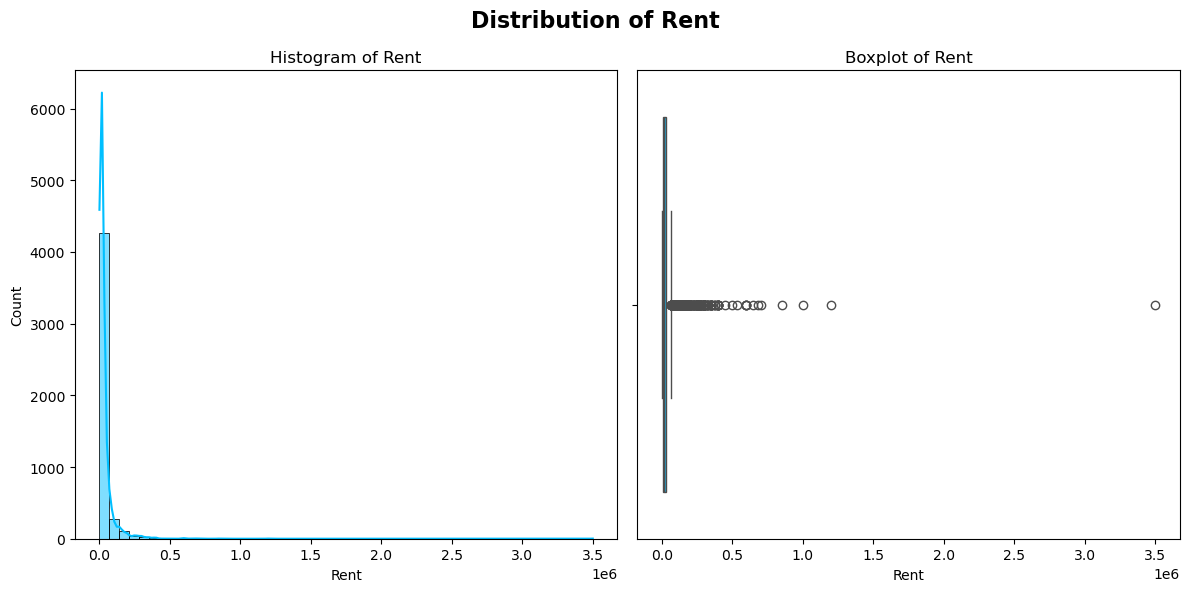

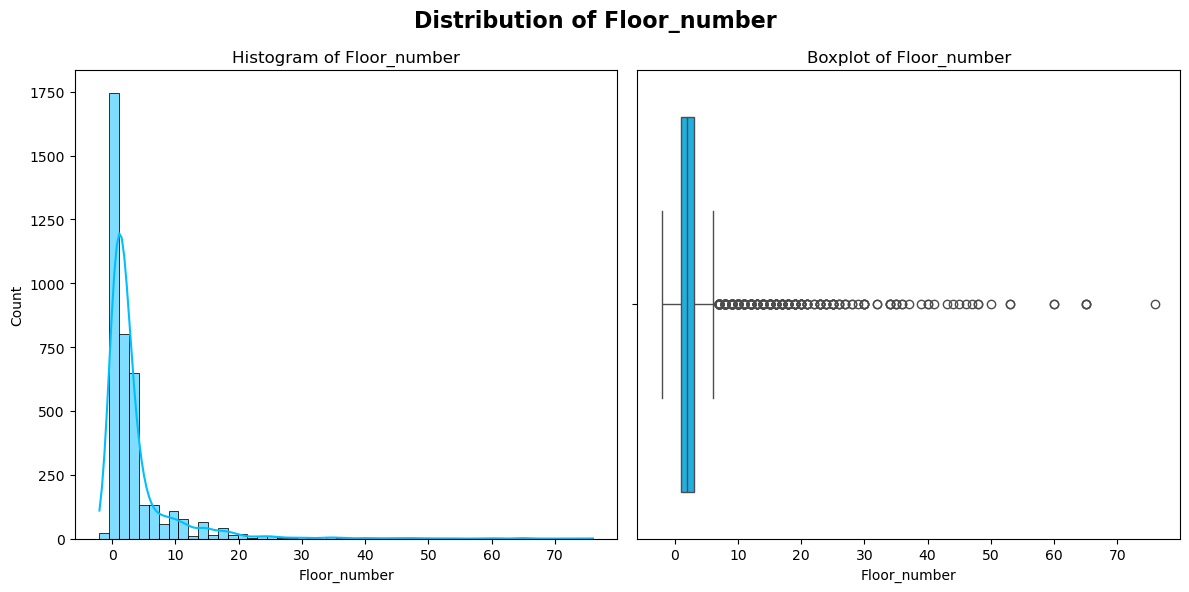

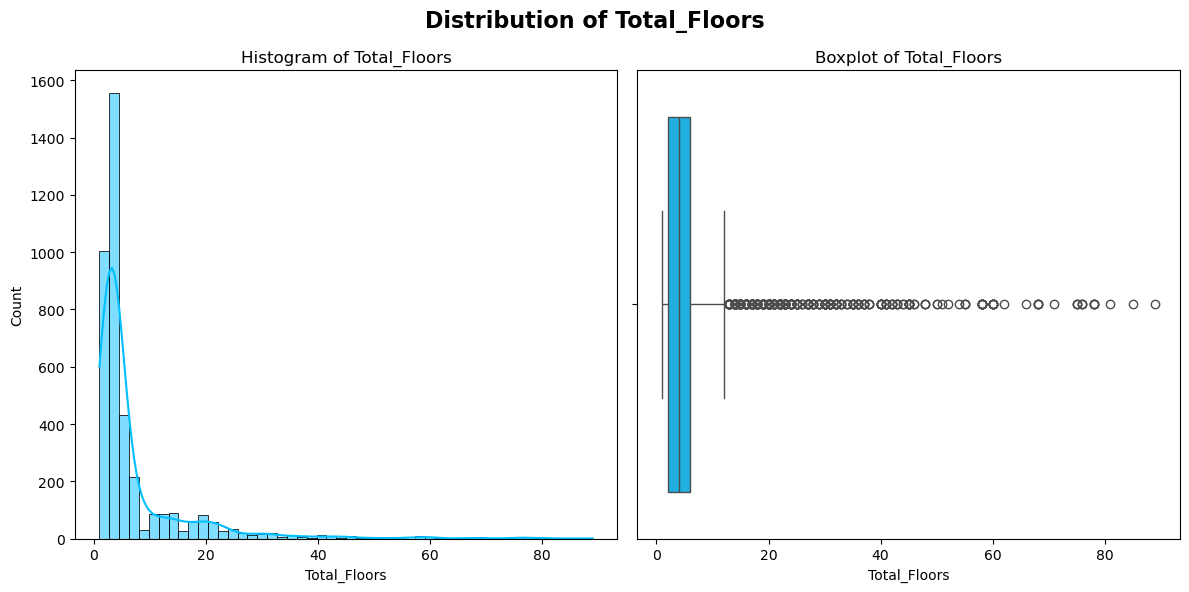

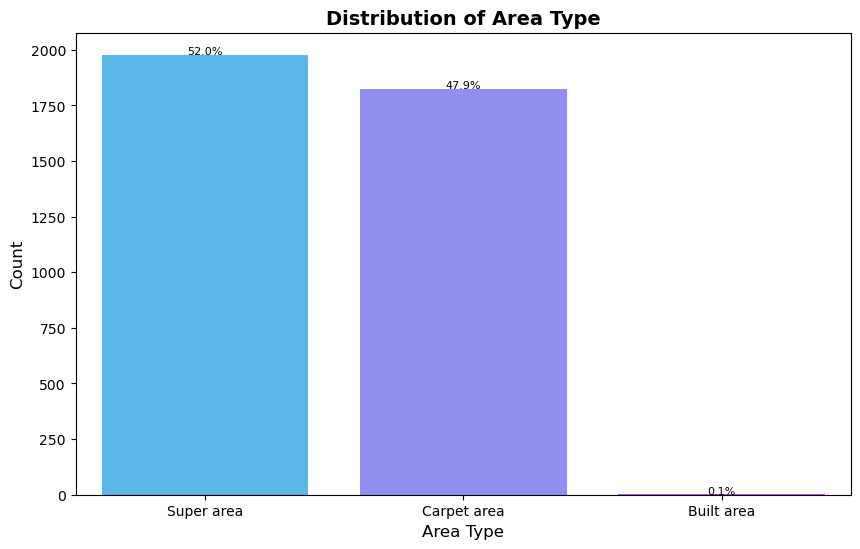

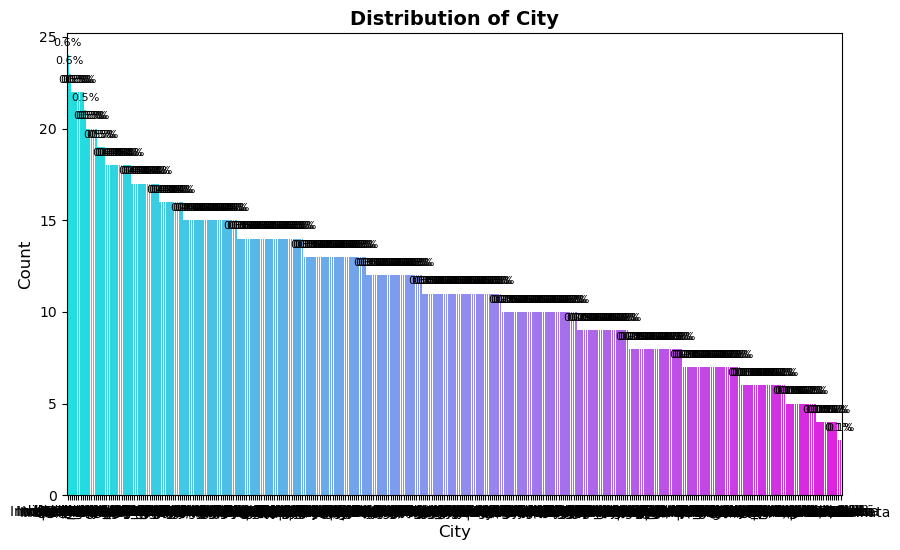

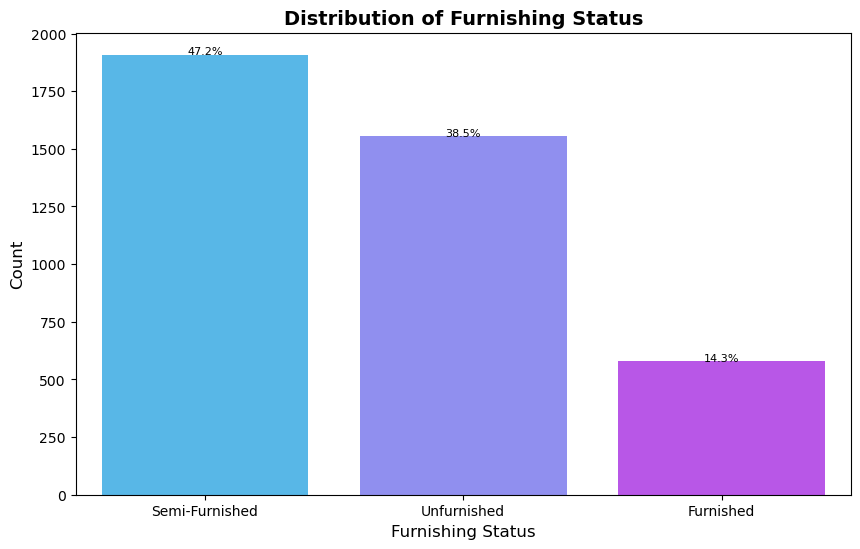

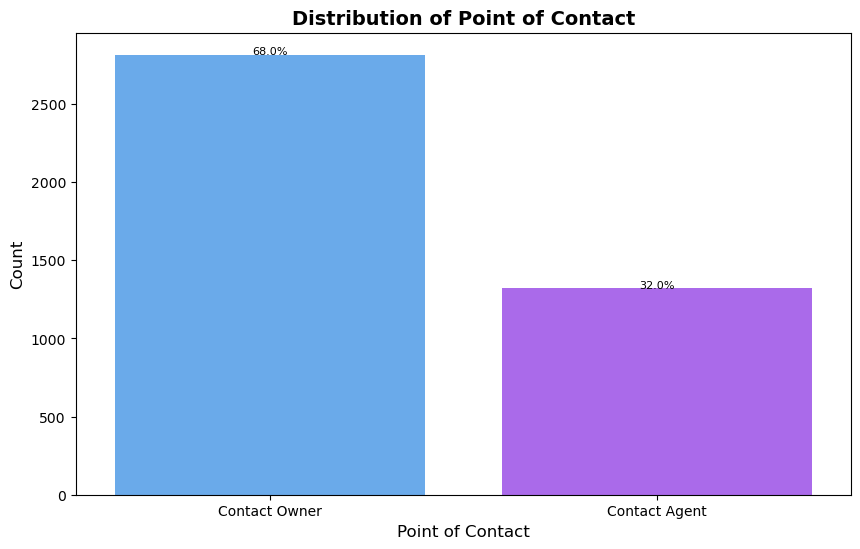

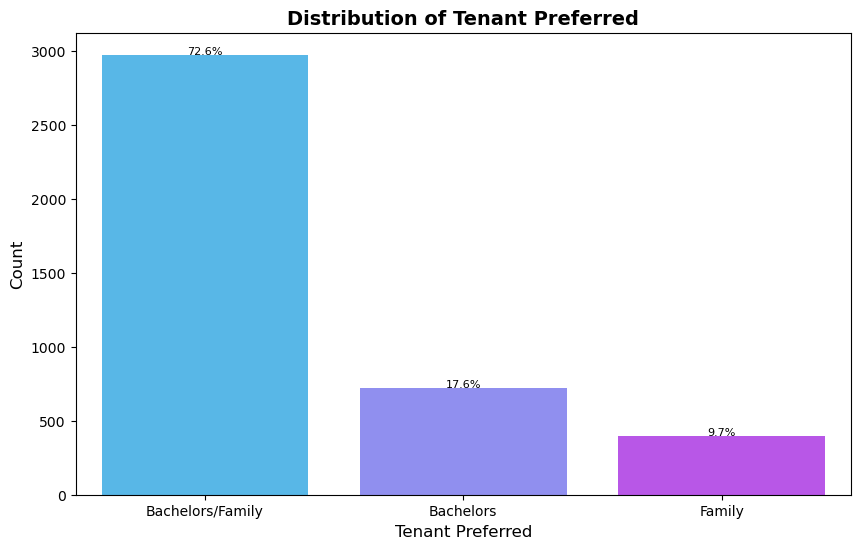

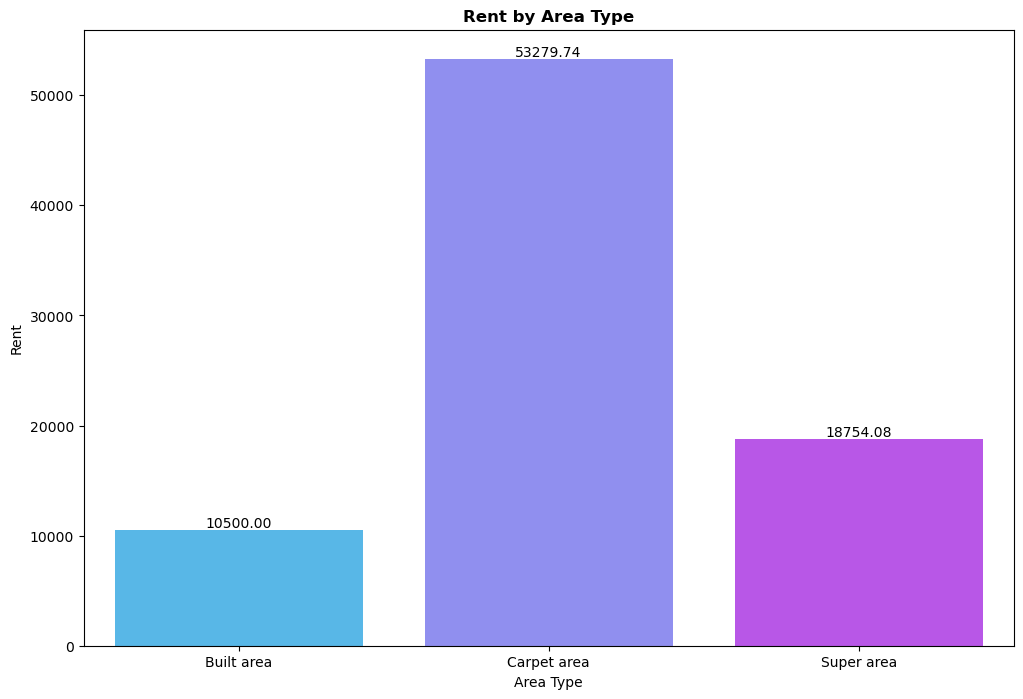

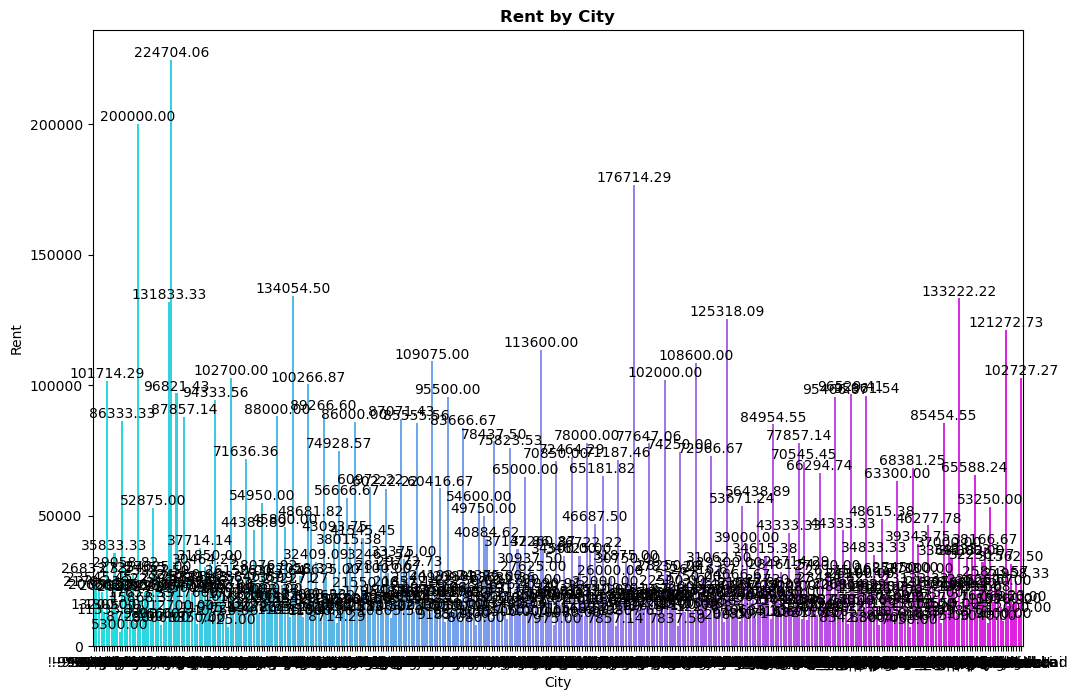

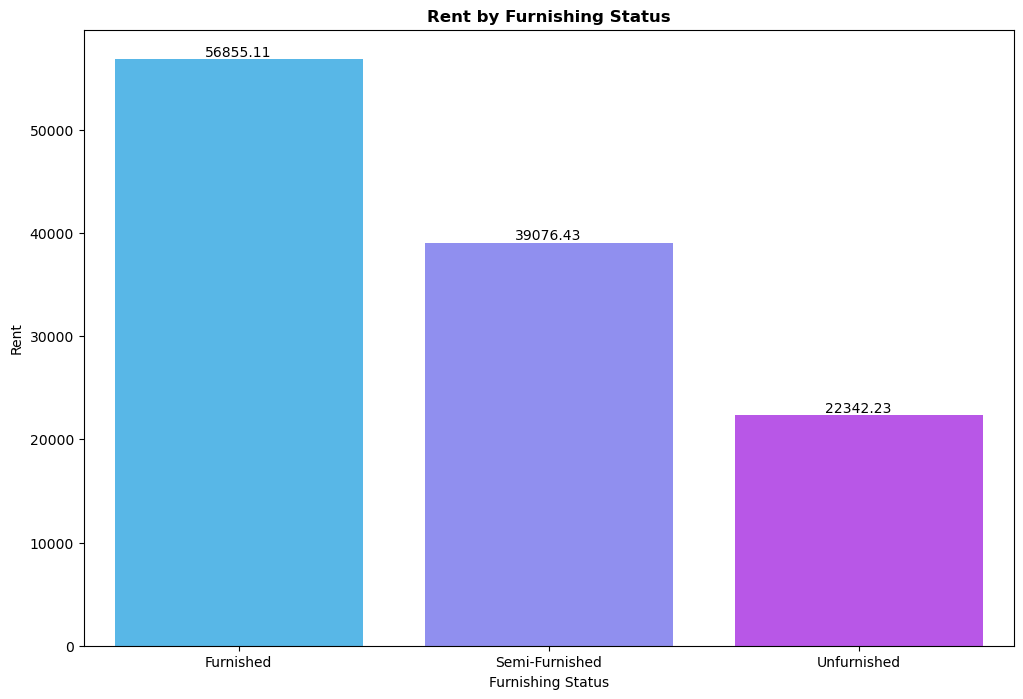

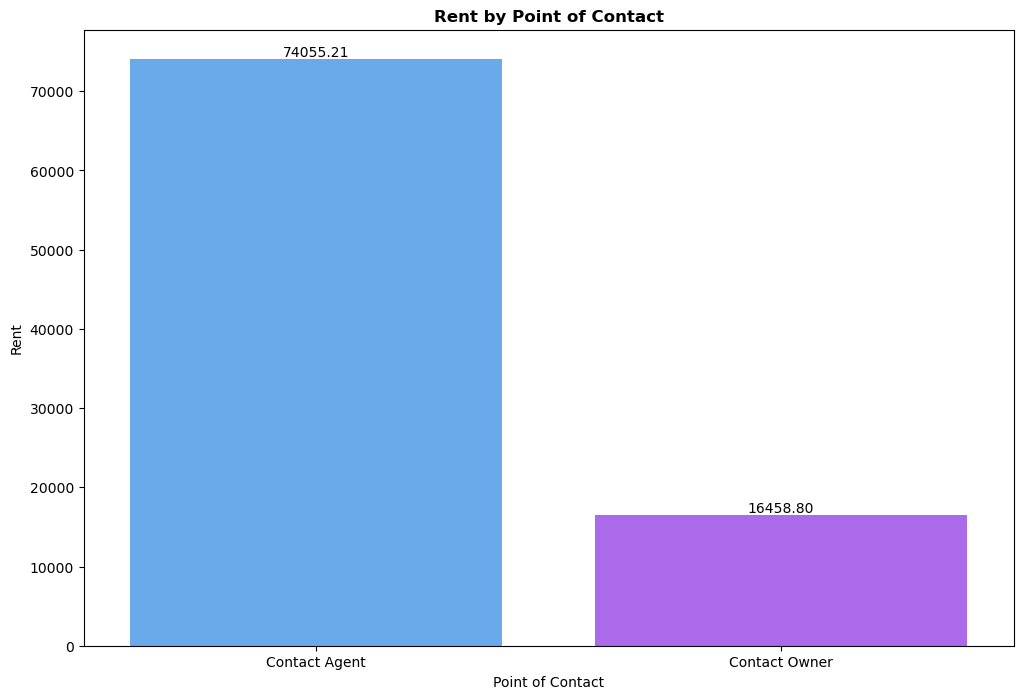

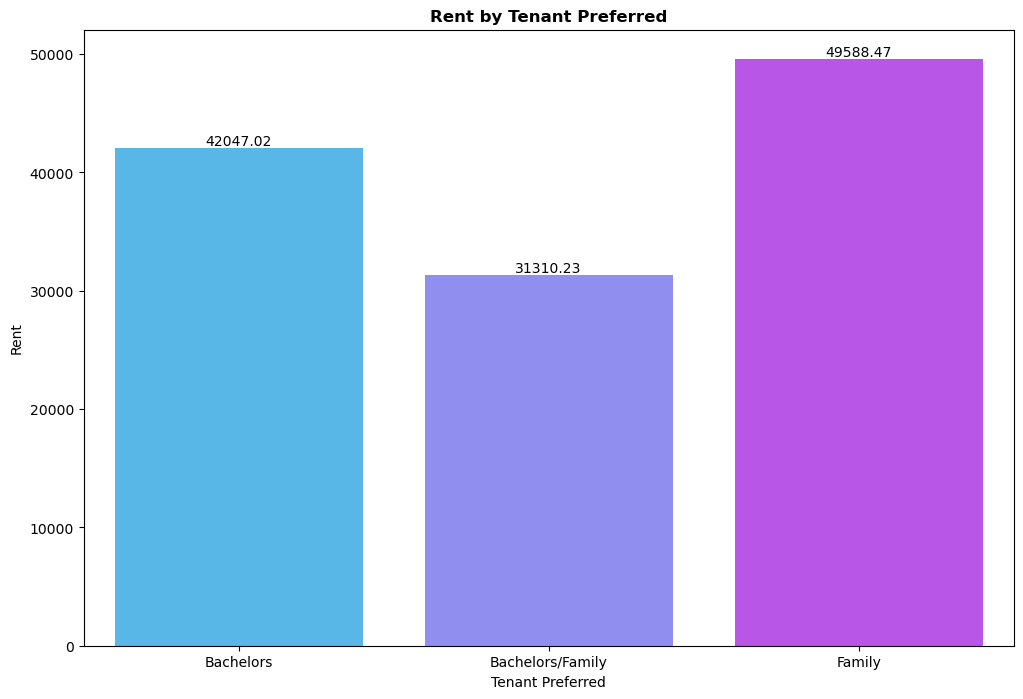

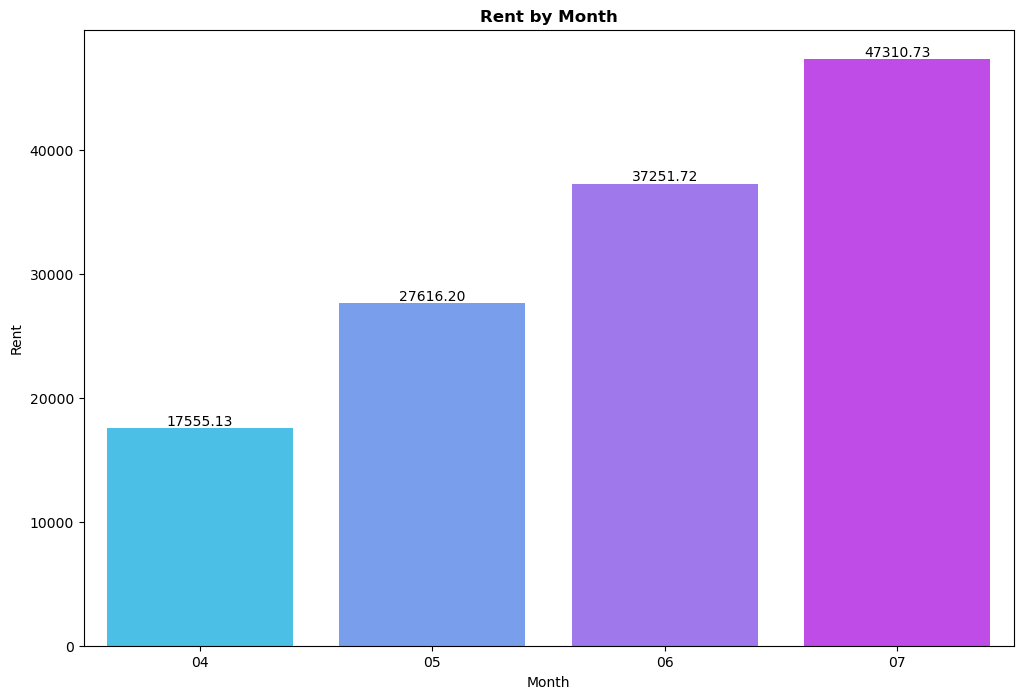

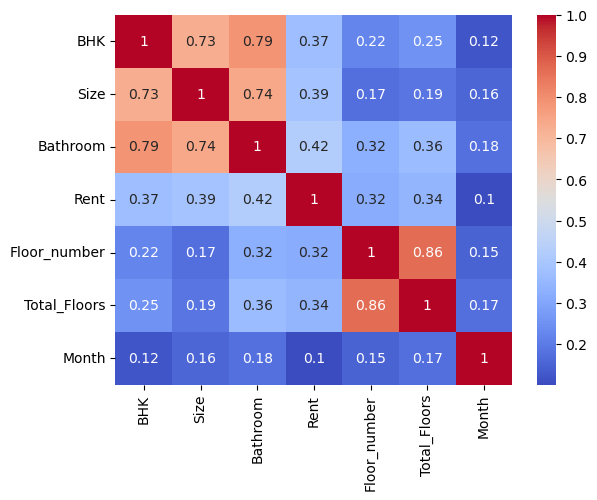

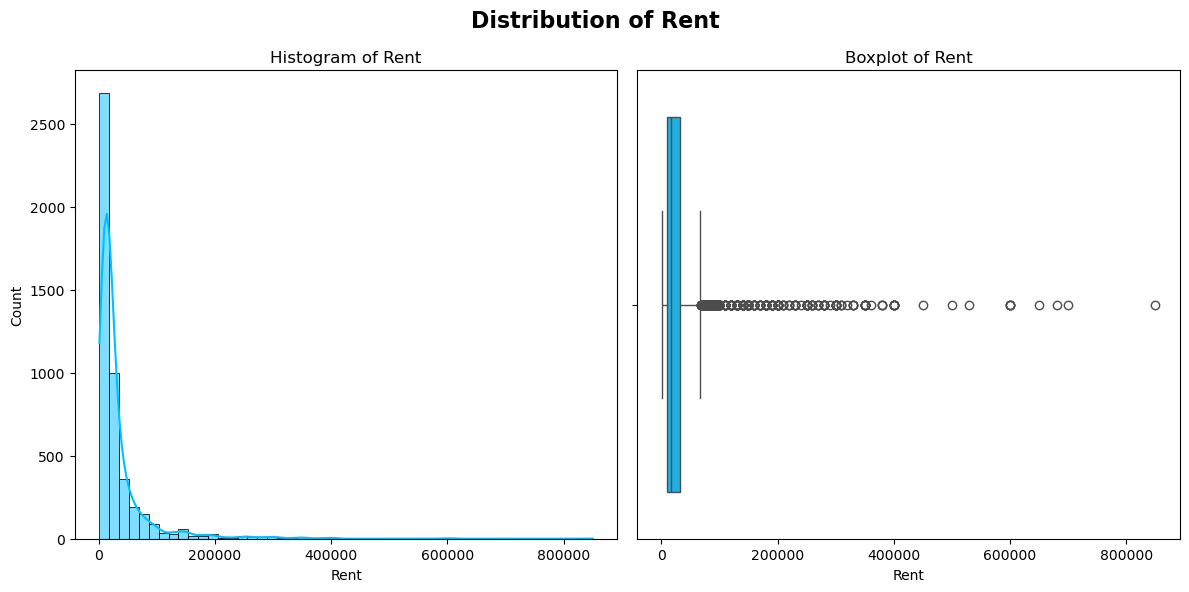

<Axes: xlabel='Total_Floors', ylabel='Rent'>

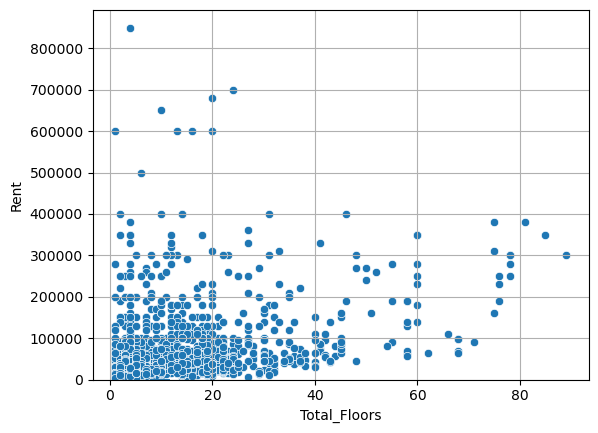

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
df = pd.read_csv("C:/Users/ADMIN/Downloads/Indian_House_Rent_Dataset.csv")
df.head()
df.info()
df.describe()
df.isnull().sum()
df['BHK'].unique()
df['BHK'] = df['BHK'].str.extract(r'(\d+)')
df['BHK'].unique()
df['BHK'].value_counts()
df['BHK'] = pd.to_numeric(df['BHK'])
df['Size'].unique()
df['Size'] = df['Size'].str.extract(r'(\d+)')
df['Size'].unique()
df['Size'] = pd.to_numeric(df['Size'])
df['Size'].describe()
df['Floor'].unique()
df['Floor_number'] = df['Floor'].str.split(" out of ").str[0]
df['Total_Floors'] = df['Floor'].str.split(" out of ").str[1]
df['Floor_number'].unique()
df['Floor_number'].replace({'Ground': 0 ,'Upper Basement':-1 , 'Lower Basement':-2}, inplace=True)
df['Floor_number'].unique()
df['Total_Floors'].unique()
df['Floor_number'] = pd.to_numeric(df['Floor_number'])
df['Total_Floors'] = pd.to_numeric(df['Total_Floors'])
df['Area Type'].unique()
df['Area Type'] = df['Area Type'].str.capitalize()
df['Area Type'].unique()
df['Area Locality'].sample(20)
df['City'].unique()
df['Furnishing Status'].unique()
df['Tenant Preferred'].unique()
df['Tenant Preferred'] = df['Tenant Preferred'].str.replace(r'[^a-zA-Z]', '', regex=True)
df['Tenant Preferred'].unique()
df['Tenant Preferred'] = df['Tenant Preferred'].str.replace('BachelorsFamily', 'Bachelors/Family')
df['Tenant Preferred'].unique()
df['Bathroom'].unique()
df['Bathroom'] = df['Bathroom'].str.extract(r'(\d+)')
df['Bathroom'] = pd.to_numeric(df['Bathroom'])
df['Point of Contact'].unique()
df.info()
df.columns
def num_plot(column):
  fig, ax = plt.subplots(1, 2, figsize = (12,6))
  # ax = ax.flatten()
  fig.suptitle(f"Distribution of {column}", fontsize=16, fontweight='bold')
  sns.histplot(x=column, data=df, bins = 50,kde=True, edgecolor='black', ax=ax[0],color = 'deepskyblue')
  ax[0].set_title(f"Histogram of {column}")
  sns.boxplot(x=column, data=df, ax=ax[1],color = 'deepskyblue')
  ax[1].set_title(f"Boxplot of {column}")
  plt.tight_layout()
  plt.show()
num_columns = df.select_dtypes(include=['number']).columns
for column in num_columns:
    num_plot(column)
df.select_dtypes(include=['object', 'category']).columns
Cat_columns = df.select_dtypes(include=['object', 'category']).columns
def cat_bar_plot(column, df):
    plt.figure(figsize=(10, 6))

    data_counts = df[column].value_counts()
    total = data_counts.sum()
    percentages = (data_counts / total) * 100
    ax = sns.barplot(x=data_counts.index, y=data_counts.values, palette="cool")
    for i, count in enumerate(data_counts.values):
        percentage = f"{percentages[i]:.1f}%"
        ax.text(i, count + 0.5, percentage, ha='center', fontsize=8,  color='black')

    plt.xlabel(column, fontsize=12)
    plt.ylabel("Count", fontsize=12)
    plt.title(f"Distribution of {column}", fontsize=14, fontweight='bold')

    plt.xticks(rotation=0)
    plt.show()
for column in Cat_columns.difference(['Posted On','Area Locality','Floor']):
    cat_bar_plot(column,df)
def cat_target_bar_plot(column):
    data = df.groupby(column)['Rent'].mean().reset_index()
    plt.figure(figsize=(12, 8))
    ax = sns.barplot(x=column,y='Rent',data=data,palette='cool',errorbar=None)
    plt.title(f'Rent by {column}',fontdict={'fontweight':'bold'})
    for container in ax.containers:
        ax.bar_label(container, fmt='%.2f', label_type='edge', fontsize=10, color='black')
    plt.xticks(rotation=0)
    plt.show()
for column in Cat_columns.difference(['Posted On','Area Locality','Floor']):
    cat_target_bar_plot(column)
df['Posted On'].unique()
df['Month']= df['Posted On'].str.split('-', n=3).str[1]
df['Month'].unique()
cat_target_bar_plot('Month')
df['Month'] = pd.to_numeric(df['Month'])
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap='coolwarm')
df['Month'].value_counts()
df['Month'].isna().sum()
df.loc[df['Rent'] == df['Rent'].max(),:]
df.loc[(df['Size'] == 2500.0) & (df['City'] == 'Bangalore'),:]
df.loc[df['Rent'] >= 1e6 ,'Rent'] = df.loc[df['Rent'] >= 1e6 ,'Rent']/10
df['Rent'].describe()
1.5*(33000 - 10000) + 33000
df.loc[df['Rent'] >= 500000.0 ,:]
df.loc[(df['Size'] == 2500.0) & (df['City'] == 'Mumbai'),:]
num_plot('Rent')
df.loc[(df['Rent'] >= 67500.0) & (df['City'] == 'Mumbai'),:]
df.loc[(df['Rent'] >= 67500.0) & (df['City'] != 'Mumbai'),:]
sns.scatterplot(x='Total_Floors',y='Rent',data=df)
np.log1p(df['Rent']).hist()



<Axes: >

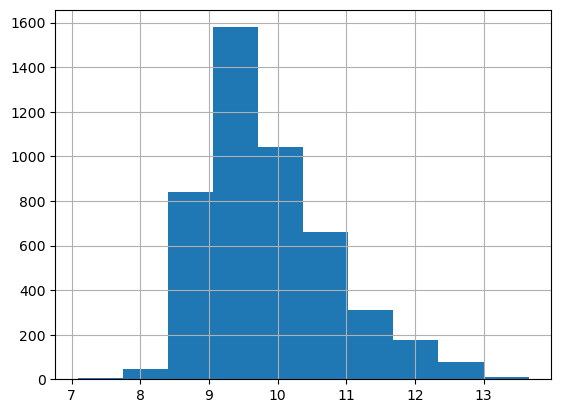

In [19]:
np.log1p(df['Rent']).hist()


<Axes: >

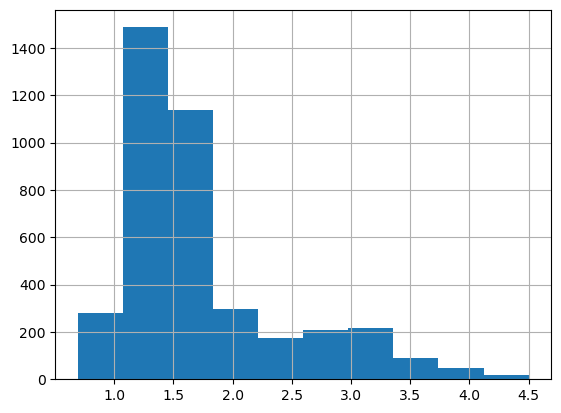

In [20]:
np.log1p(df['Total_Floors']).hist()


<Axes: >

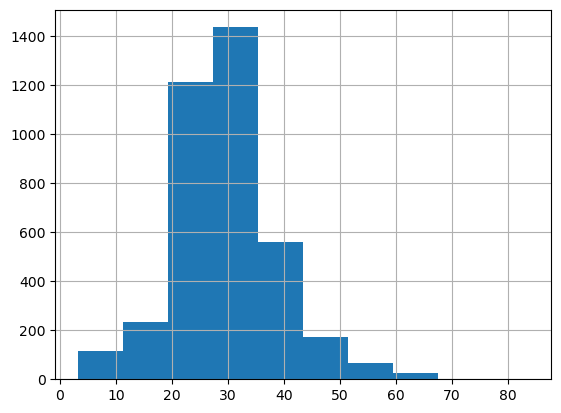

In [21]:
np.sqrt(df['Size']).hist()


<Axes: >

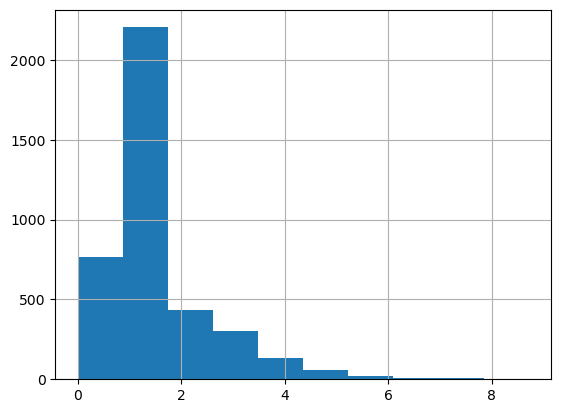

In [22]:
np.sqrt(df['Floor_number']).hist()


In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from scipy.stats import uniform, randint
X = df.drop(columns='Rent')
y = np.log1p(df['Rent'])
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
df.columns
log_cols = ['Total_Floors']
sqrt_cols = ['Size','Floor_number']
num_columns = ['Total_Floors','Size','Floor_number']
nominal_cols = ['Area Type']
ordinal_cols = ['Month','City','BHK','Bathroom','Furnishing Status','Tenant Preferred','Point of Contact']
def fillna_general(df, target_column, feature_columns):
  grouped_dict = df.groupby(feature_columns)[target_column].agg(lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan).to_dict()
  df.loc[df[target_column].isna(), target_column] = df[df[target_column].isna()].apply(
      lambda row : grouped_dict.get(tuple(row[feature] for feature in feature_columns),row[target_column]),axis=1)

  return df
class FillNaNTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, col_to_fill, ref_cols):
        self.col_to_fill = col_to_fill
        self.ref_cols = ref_cols

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        for col, refs in zip(self.col_to_fill, self.ref_cols):
            X = fillna_general(X, col, refs)
            return X

    def get_feature_names_out(self, input_features=None):
        return X_train.columns
fill_columns = {
    'BHK': ['Bathroom', 'Size'],
    'Size': ['BHK', 'Bathroom'],
    'Bathroom': ['Size', 'BHK'],
    'Floor_number': ['City'],
    'Total_Floors': ['City','Area Locality'],
    'Area Type': ['Size', 'City'],
    'City':  ['Size','Total_Floors'],
    'Furnishing Status': ['City'],
    'Tenant Preferred': ['Size','BHK'],
    'Point of Contact': ['Furnishing Status','City'],
    'Month' : ['Size','Bathroom','Rent']
}
Nan_pipeline = Pipeline([
    ("fill_nan", FillNaNTransformer(list(fill_columns.keys()), list(fill_columns.values())))
])

function_transformer = ColumnTransformer([
    ('log', FunctionTransformer(np.log1p, feature_names_out="one-to-one"), log_cols),
    ('sqrt', FunctionTransformer(np.sqrt, feature_names_out="one-to-one"), sqrt_cols)
], remainder='passthrough')

num_pipeline = Pipeline([

    ("impute_median", SimpleImputer(strategy="median")),
    ('poly', PolynomialFeatures()),
    ("scale", StandardScaler())
])

Nominal_pipeline = Pipeline([
    ("impute_frequent", SimpleImputer(strategy="most_frequent")),
    ("one_hot", OneHotEncoder(handle_unknown="ignore"))
])

Ordinal_pipeline = Pipeline([
    ("impute_frequent", SimpleImputer(strategy="most_frequent")),
    ("ordinal_encode", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1))
])
preprocessor = ColumnTransformer([
    ('numeric', make_pipeline(function_transformer, num_pipeline), num_columns),
    ('nominal', Nominal_pipeline, nominal_cols),
    ('ordinal', Ordinal_pipeline, ordinal_cols)
])
final_pipeline = Pipeline([
    ('fill_na', Nan_pipeline),
    ('preprocessor', preprocessor)
])
X_train_prep_df = pd.DataFrame(final_pipeline.fit_transform(X_train), columns=final_pipeline.get_feature_names_out())
X_train_prep_df.isna().sum()
X_train_prep_df.head(3)
X_train_prep = final_pipeline.fit_transform(X_train)
X_test_prep = final_pipeline.transform(X_test)
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import Lasso
from sklearn.linear_model import Ridge

m1 = LinearRegression()
m2 = Ridge()
m3 = Lasso()



val_scores = {}
for model in [m1, m2, m3]:
    scores = cross_val_score(model, X_train_prep, y_train, cv = 5, scoring = 'neg_mean_squared_error')
    val_scores[model] = scores
val_scores
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.metrics import mean_squared_error
import numpy as np
models = {
    "random forest": RandomForestRegressor(),
    "Decision Tree": DecisionTreeRegressor(),
    "SVR": SVR(),
    "XGBoost": XGBRegressor(),
    "Extra Trees": ExtraTreesRegressor()
}

mse_results = {}

for name, model in models.items():
    pipeline = Pipeline([
        ('final_pipeline', final_pipeline),
        (name, model)
    ])
    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)

    mse = mean_squared_error(y_test, y_pred)
    mse_results[name] = mse
    print(f"{name} MSE: {mse:.4f}")

NameError: name 'df' is not defined

In [1]:
pip install xgboost


Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement xgboost (from versions: none)
ERROR: No matching distribution found for xgboost
